# The Severity Prediction of The Binary And Multi-Class Cardiovascular Disease -- A Machine Learning-Based Fusion Approach: AIDI 1002 Final Term Project Report

**Arpitha Thippeswamy (200566967)**
####  Email: 200566967@student.georgianc.on.ca

**Poojaben Ribadiya (200575833)**
####  Emails: 200575833@student.georgianc.on.ca

# Introduction:

The field of cardiovascular disease (CVD) prediction through machine learning has witnessed significant attention due to the rising global prevalence of CVDs. As a leading cause of mortality worldwide, the accurate prediction of cardiovascular diseases becomes imperative for timely intervention and improved patient outcomes.

## Problem Description:
In this study, the focus is on developing a predictive model for the severity of cardiovascular diseases using a machine learning-based fusion approach. The severity prediction is a critical aspect of CVD management, allowing healthcare professionals to tailor interventions based on the expected progression of the disease. The challenge lies in accurately predicting the severity levels, considering the multifaceted nature of cardiovascular conditions.

## Context of the Problem:

The importance of predicting cardiovascular disease severity cannot be overstated, given the alarming global statistics associated with CVD-related deaths. As of [mention the latest available statistics], CVDs contribute significantly to the overall mortality rate, with conditions such as strokes and heart attacks being major contributors. Timely identification of individuals at high risk of developing severe cardiovascular complications is vital for implementing preventative measures and personalized treatment plans.

## Limitation About other Approaches:

While prior approaches to cardiovascular disease prediction through machine learning have shown promise, they often face limitations in handling the complexity and multi-class nature of severity prediction. Existing models may struggle to provide accurate predictions across different severity levels, potentially leading to suboptimal clinical decisions. The forthcoming background section will delve into the specifics of these limitations, providing a comprehensive understanding of the challenges that necessitate the proposed fusion approach.

## Solution:

The method we are discussing involves creating fusion models by combining different machine learning algorithms for binary classification. In our contribution trial, we utilized a combination of k-Nearest Neighbors (KNN) and Gradient Boosting, achieving accuracy values comparable to or even exceeding the accuracy of individual models in the original research. This approach demonstrates the effectiveness of combining diverse algorithms to enhance predictive performance. By leveraging fusion models, we aim to optimize accuracy in binary classification, addressing the challenge of achieving robust and reliable predictions for cardiovascular disease severity.

# Background

| Reference |Explanation |  Dataset/Input |Weakness
| --- | --- | --- | --- |
| Ayman Mir and Sudhir N Dhage.[23] | They have applied four data mining algorithms to a diabetes dataset using the WEKA tool, with SVM achieving the highest f1-score of 78.2%.|  diabetes dataset  | Only 78.2% f1 score and lack of comprehensive evaluation beyond the highest F1-score, neglecting a broader spectrum of performance metrics.
| Haleh Ayatollahi, Leila Gholamhosseini, and Masoud Salehi.[14]|They used SVM and ANN for the diagnosis of cardiovascular disease, achieving high efficiency with SVM. Applied standardized decision support model with SVM (linear, polynomial, and radial) procedures. |cardiovascular dataset |low accuracy and  limited exploration of overfitting risks and generalization challenges with multiple SVM procedures and weighted score fusion

# Methodology

![Proposed architecture](proposed%20architecture.png "Proposed architecture, location is simply the directory of the notebook")

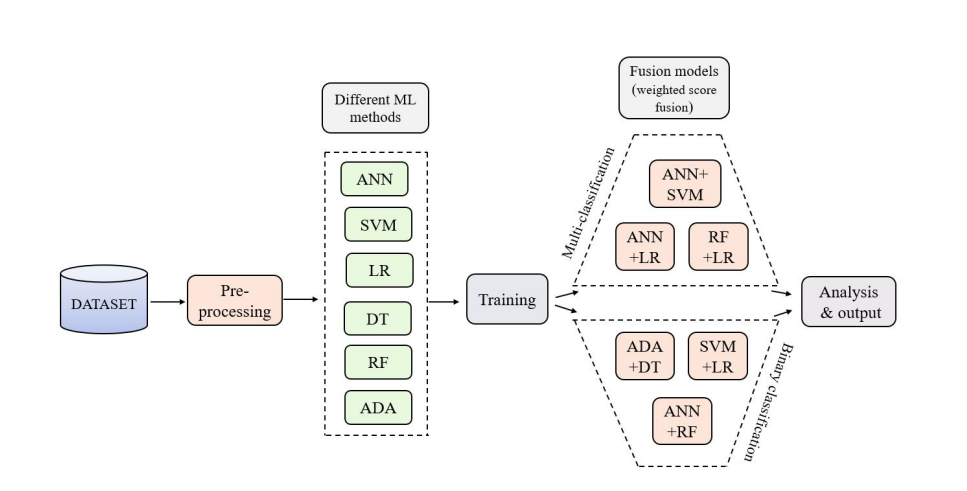

In [34]:
from IPython.display import Image

# Replace 'image_filename.png' with the actual filename of your image

Image('sample_data/proposed architecture.png')

<li>In this quantitative research focused on predicting heart disease severity, secondary data was employed to address a real-world problem. The study involved the development of two classification models: a multi-classification system with five classes measuring disease severity, and a binary classification distinguishing patients with or without heart disease.</li>
<li>Six machine learning algorithms were selected based on performance, and three fused models were created by combining these algorithms. The fusion strategy considered algorithms with similar accuracies for optimal results. Two exceptions, fusion model-1 for multi-classification (80:20 split) and fusion model-1 for binary classification (70:30 split), were handled by random testing due to unsatisfactory outcomes.</li>
<li>Pre-processing steps included cleaning, replacing missing values, and feature scaling. Imbalanced data for multi-classification was addressed through oversampling. Fusion models utilized a weighted sum rule, and standardization was unnecessary before merging, as individual model outputs shared the same score range.</li>

**The proposed methodology is illustrated in the visual above with slight variations in the arrangement of fusion models for binary and multi-classification.The fusion models used for binary classifcation are (AdaBoost,Decision Tree),(SupportVectorMachine,Logistic Regression),(Artifical Neural Network,Random Forest) and that for multi classification are (Artifical Neural Network,SupportVectorMachines),(Artifical Neural Network,LogisticRregression),(RandomForest,LogisticRregression)**

# Implementation

# Replication code : 1. Binary classification


In [3]:
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Dense ,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from tensorflow.keras.optimizers import Adam,SGD
from matplotlib import pyplot as plt
import numpy
import numpy as np
from sklearn.metrics import classification_report
import sklearn.metrics as metrics
import pandas as pd

dataset = pd.read_csv("/content/sample_data/binary classification.csv")
dataset_array = dataset.to_numpy()
x = dataset_array[:, 0:13]  # Extracting features from columns 0 to 12
y = dataset_array[:, 13]    # Extracting labels from column 13

#for 80:20 ratio
#X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

#for 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)

#StandardScaler for normalization for some algortihms
sc = StandardScaler()

#min-max scaler for normalization for some algortihms
scaler = MinMaxScaler(feature_range=(0,1))


In [4]:
"""Information based algorithms (Decision Trees, Random Forests) and probability based algorithms (Naive Bayes, Bayesian Networks) don't require normalization either."""

#code for RF

from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=100)

model3.fit(X_train,y_train)
rounded_predictions3 = model3.predict(X_test)
predictions3 =model3.predict_proba(X_test)
y_pred3 = rounded_predictions3


import sklearn.metrics as metrics
scores3=metrics.accuracy_score(y_test,y_pred3)
print("RF",scores3)

print(metrics.confusion_matrix(y_test,y_pred3))
print(metrics.classification_report(y_test,y_pred3))


fpr3, tpr3, threshold = metrics.roc_curve(y_test, y_pred3)
roc_auc3 = metrics.auc(fpr3, tpr3)
print("roc_auc_RF",roc_auc3)


RF 0.7472527472527473
[[36  9]
 [14 32]]
              precision    recall  f1-score   support

         0.0       0.72      0.80      0.76        45
         1.0       0.78      0.70      0.74        46

    accuracy                           0.75        91
   macro avg       0.75      0.75      0.75        91
weighted avg       0.75      0.75      0.75        91

roc_auc_RF 0.7478260869565219


In [5]:
from tensorflow.keras.regularizers import l2
# StandardScaler for normalization
scaler = StandardScaler()

# Scale the training and testing data
scaled_X_train_ann = scaler.fit_transform(X_train)
scaled_X_test_ann = scaler.transform(X_test)

# Define the ANN model
model2 = Sequential()
model2.add(Dense(8, input_dim=13, activation='relu', kernel_regularizer=l2(0.01)))
model2.add(Dense(1, activation='sigmoid'))

# Use learning_rate instead of lr
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model2.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

# Train the ANN model
history = model2.fit(scaled_X_train_ann, y_train, validation_split=0.1, batch_size=10, epochs=15, shuffle=True, verbose=2)

# Make predictions on the test data
predictions2 = model2.predict(scaled_X_test_ann, batch_size=5, verbose=0)
rounded_predictions2 = np.round(predictions2).astype(int)
y_pred2 = rounded_predictions2

# Evaluate the ANN model
score2 = metrics.accuracy_score(y_test, y_pred2)
print("ANN", score2)

print(metrics.confusion_matrix(y_test, y_pred2))
print(metrics.classification_report(y_test, y_pred2))

fpr2, tpr2, threshold = metrics.roc_curve(y_test, y_pred2)
roc_auc2 = metrics.auc(fpr2, tpr2)
print("roc_auc_ann", roc_auc2)

Epoch 1/15
19/19 - 1s - loss: 0.8609 - accuracy: 0.5316 - val_loss: 0.7070 - val_accuracy: 0.7727 - 1s/epoch - 60ms/step
Epoch 2/15
19/19 - 0s - loss: 0.6242 - accuracy: 0.7737 - val_loss: 0.5607 - val_accuracy: 0.7727 - 60ms/epoch - 3ms/step
Epoch 3/15
19/19 - 0s - loss: 0.5435 - accuracy: 0.8053 - val_loss: 0.5155 - val_accuracy: 0.7727 - 72ms/epoch - 4ms/step
Epoch 4/15
19/19 - 0s - loss: 0.4846 - accuracy: 0.8211 - val_loss: 0.5031 - val_accuracy: 0.7727 - 64ms/epoch - 3ms/step
Epoch 5/15
19/19 - 0s - loss: 0.4405 - accuracy: 0.8474 - val_loss: 0.4923 - val_accuracy: 0.7727 - 76ms/epoch - 4ms/step
Epoch 6/15
19/19 - 0s - loss: 0.4090 - accuracy: 0.8684 - val_loss: 0.4987 - val_accuracy: 0.7727 - 78ms/epoch - 4ms/step
Epoch 7/15
19/19 - 0s - loss: 0.3837 - accuracy: 0.8947 - val_loss: 0.5051 - val_accuracy: 0.8182 - 56ms/epoch - 3ms/step
Epoch 8/15
19/19 - 0s - loss: 0.3632 - accuracy: 0.8947 - val_loss: 0.5031 - val_accuracy: 0.8182 - 63ms/epoch - 3ms/step
Epoch 9/15
19/19 - 0s - l

In [6]:
#weighted fusion
#same procedure for every model(1,2 and 3). for every model we need to take the prediction
# values and then the values will be merged according to the procedure given in below.

#selecting the best value for p and q(p & q represents the weights w1 & w2)
p=1
#q=1-p
for i in range (19):
    p=p-.05
    q=1-p


    mixed=predictions3[:,1]*p+predictions2[:,0]*q
    rounded_mixed=mixed
    for i in range(len(y_test)):
        if mixed[i]>.5:
            rounded_mixed[i]=1
        else:
            rounded_mixed[i]=0

    score=metrics.accuracy_score(rounded_mixed,y_test)
    print("  mixed  p  q","%.4f" %score, "%.2f" %p,"%.2f" %q)

    #after selecting the value of p and q which gives the highest accuracy. This value differs for different algorithms.

p=.05
q=1-p

mixed=predictions3[:,1]*p+predictions2[:,0]*q
rounded_mixed=mixed
for i in range(len(y_test)):
    if mixed[i]>=.5:
        rounded_mixed[i]=1
    else:
         rounded_mixed[i]=0

score=metrics.accuracy_score(rounded_mixed,y_test)
print("mixed",score)

print(metrics.confusion_matrix(y_test,rounded_mixed))
print(metrics.classification_report(y_test,rounded_mixed))

fpr, tpr, threshold = metrics.roc_curve(rounded_mixed,y_test)
roc_auc = metrics.auc(fpr, tpr)
print("roc_auc_tot",roc_auc)

  mixed  p  q 0.7473 0.95 0.05
  mixed  p  q 0.7473 0.90 0.10
  mixed  p  q 0.7473 0.85 0.15
  mixed  p  q 0.7582 0.80 0.20
  mixed  p  q 0.7582 0.75 0.25
  mixed  p  q 0.7802 0.70 0.30
  mixed  p  q 0.7802 0.65 0.35
  mixed  p  q 0.7802 0.60 0.40
  mixed  p  q 0.7802 0.55 0.45
  mixed  p  q 0.7802 0.50 0.50
  mixed  p  q 0.7802 0.45 0.55
  mixed  p  q 0.7802 0.40 0.60
  mixed  p  q 0.7802 0.35 0.65
  mixed  p  q 0.7802 0.30 0.70
  mixed  p  q 0.7802 0.25 0.75
  mixed  p  q 0.7802 0.20 0.80
  mixed  p  q 0.7802 0.15 0.85
  mixed  p  q 0.7802 0.10 0.90
  mixed  p  q 0.7802 0.05 0.95
mixed 0.7802197802197802
[[39  6]
 [14 32]]
              precision    recall  f1-score   support

         0.0       0.74      0.87      0.80        45
         1.0       0.84      0.70      0.76        46

    accuracy                           0.78        91
   macro avg       0.79      0.78      0.78        91
weighted avg       0.79      0.78      0.78        91

roc_auc_tot 0.7889771598808342


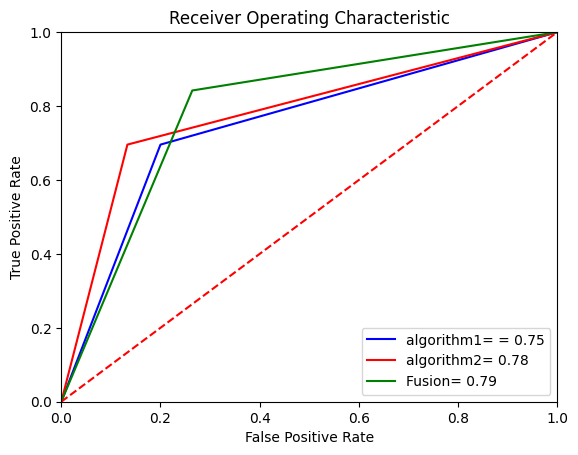

In [7]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr3, tpr3, 'b', label = 'algorithm1= = %0.2f' % roc_auc3)
plt.plot(fpr2, tpr2, 'r', label = 'algorithm2= %0.2f' % roc_auc2)
plt.plot(fpr, tpr, 'g', label = 'Fusion= %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Replication code : Multi Classification

In [8]:
from keras.models import Sequential
from keras.layers import Dense,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from tensorflow.keras.optimizers import Adam,SGD
from matplotlib import pyplot as plt
import numpy
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import numpy as np

In [9]:
dataset = pd.read_csv("/content/sample_data/multiclassification.csv", delimiter=",")
dataset_array = dataset.to_numpy()
x = dataset_array[:,0:13]
y = dataset_array[:,13]

In [10]:
#for 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

#for 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)


In [11]:
X_train.shape

(212, 13)

In [12]:
from pandas import read_csv
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder

Class=0, n=121 (57.075%)
Class=2, n=23 (10.849%)
Class=4, n=11 (5.189%)
Class=1, n=31 (14.623%)
Class=3, n=26 (12.264%)


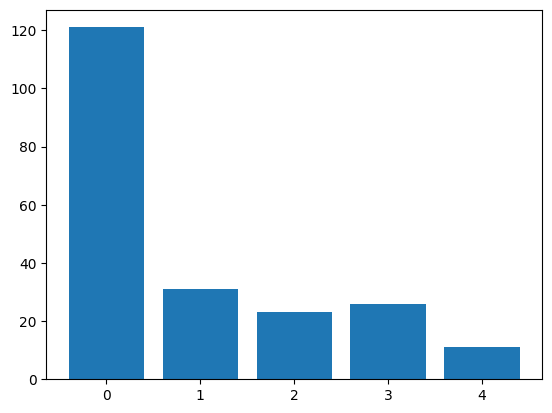

In [13]:
# summarize distribution
counter = Counter(y_train)
for k,v in counter.items():
	per = v / len(y_train) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

##### Over Sampling

In [14]:
from imblearn.over_sampling import RandomOverSampler

In [15]:
os=RandomOverSampler()
X_train_ns,y_train_ns=os.fit_resample(X_train,y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

The number of classes before fit Counter({0.0: 121, 1.0: 31, 3.0: 26, 2.0: 23, 4.0: 11})
The number of classes after fit Counter({0.0: 121, 2.0: 121, 4.0: 121, 1.0: 121, 3.0: 121})


Class=0, n=121 (20.000%)
Class=2, n=121 (20.000%)
Class=4, n=121 (20.000%)
Class=1, n=121 (20.000%)
Class=3, n=121 (20.000%)


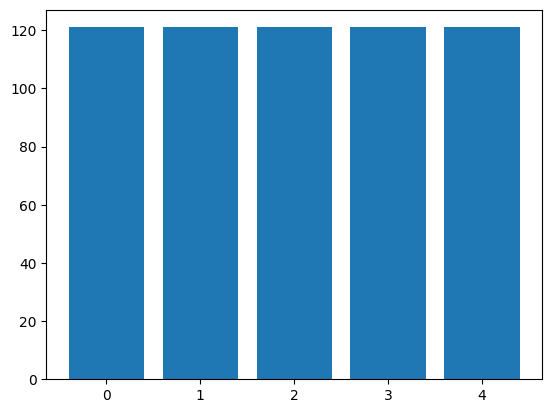

In [16]:
# summarize distribution
counter = Counter(y_train_ns)
for k,v in counter.items():
	per = v / len(y_train_ns) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

In [17]:
X_train=X_train_ns
y_train=y_train_ns

In [18]:
X_train.shape

(605, 13)

In [19]:
#StandardScaler for normalization for some algortihms
sc = StandardScaler()

#min-max scaler for normalization for some algortihms
scaler = MinMaxScaler(feature_range=(0,1))

In [20]:
#code for svm

from sklearn.svm import SVC
model1 = SVC(probability=True,C=.01)

X_train_scaled = sc.fit_transform(X_train)
X_train_svc=X_train_scaled[:,0:13]
X_test_scaled = sc.transform(X_test)
X_test_svc=X_test_scaled[:,0:13]


model1.fit(X_train_svc,y_train)
rounded_predictions1 = model1.predict(X_test_svc)
predictions1 =model1.predict_proba(X_test_svc)
y_pred1 = rounded_predictions1

import sklearn.metrics as metrics
scores=metrics.accuracy_score(y_test,y_pred1)
print("SVM",scores)

print(metrics.confusion_matrix(y_test,y_pred1))
print(metrics.classification_report(y_test,y_pred1))

SVM 0.4065934065934066
[[30  8  2  1  3]
 [ 8  2  4  5  4]
 [ 4  1  2  4  2]
 [ 0  0  5  2  2]
 [ 0  0  0  1  1]]
              precision    recall  f1-score   support

         0.0       0.71      0.68      0.70        44
         1.0       0.18      0.09      0.12        23
         2.0       0.15      0.15      0.15        13
         3.0       0.15      0.22      0.18         9
         4.0       0.08      0.50      0.14         2

    accuracy                           0.41        91
   macro avg       0.26      0.33      0.26        91
weighted avg       0.43      0.41      0.41        91



In [21]:
# code for ANN
import keras
from keras.models import Sequential
from keras import regularizers
from keras.regularizers import l2
from keras.layers import Dense ,BatchNormalization
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_auc_score
from tensorflow.keras.optimizers.legacy import Adam,SGD
from sklearn.preprocessing import MinMaxScaler,StandardScaler

scaler = MinMaxScaler(feature_range=(0,1))
# Define a Deep Learning Model
model4 = keras.models.Sequential()
model4.add(Dense(8, input_dim=13,use_bias=True,bias_initializer='zeros', activation='relu', kernel_regularizer=l2(0.01) ))
model4.add(Dense(5, activation='softmax'))
sgd = SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model4.compile(loss='sparse_categorical_crossentropy', optimizer='sgd',metrics=['accuracy'])



#Normalize train & test sample
scaled_X_train_ann=scaler.fit_transform(X_train)
scaled_X_test_ann=scaler.transform(X_test)
# Train the Model

history=model4.fit(scaled_X_train_ann, y_train,validation_split=0.1, batch_size=5,epochs=20,shuffle=True,verbose=2)


predictions4 = model4.predict(scaled_X_test_ann,batch_size=5,verbose=0)
#rounded_predictions4 = model4.predict_classes(scaled_X_test_ann,batch_size=5,verbose=0)
rounded_predictions4=np.argmax(predictions4,axis=1)
y_pred4 = rounded_predictions4


#print(predictions)
import sklearn.metrics as metrics
scores4=metrics.accuracy_score(y_test,y_pred4)
print("ANN",scores4)

print(metrics.confusion_matrix(y_test,y_pred4))
print(metrics.classification_report(y_test,y_pred4))

Epoch 1/20
109/109 - 1s - loss: 1.6938 - accuracy: 0.1838 - val_loss: 1.6491 - val_accuracy: 0.5082 - 788ms/epoch - 7ms/step
Epoch 2/20
109/109 - 0s - loss: 1.6616 - accuracy: 0.2647 - val_loss: 1.7214 - val_accuracy: 0.0000e+00 - 181ms/epoch - 2ms/step
Epoch 3/20
109/109 - 0s - loss: 1.6346 - accuracy: 0.3217 - val_loss: 1.8028 - val_accuracy: 0.0000e+00 - 179ms/epoch - 2ms/step
Epoch 4/20
109/109 - 0s - loss: 1.6091 - accuracy: 0.3658 - val_loss: 1.8485 - val_accuracy: 0.0000e+00 - 185ms/epoch - 2ms/step
Epoch 5/20
109/109 - 0s - loss: 1.5854 - accuracy: 0.3511 - val_loss: 1.8863 - val_accuracy: 0.0000e+00 - 197ms/epoch - 2ms/step
Epoch 6/20
109/109 - 0s - loss: 1.5628 - accuracy: 0.3346 - val_loss: 1.9710 - val_accuracy: 0.0000e+00 - 186ms/epoch - 2ms/step
Epoch 7/20
109/109 - 0s - loss: 1.5371 - accuracy: 0.3566 - val_loss: 2.0298 - val_accuracy: 0.0000e+00 - 186ms/epoch - 2ms/step
Epoch 8/20
109/109 - 0s - loss: 1.5136 - accuracy: 0.3493 - val_loss: 2.0501 - val_accuracy: 0.0000e+

In [22]:

#weighted fusion
#same procedure for every model(1,2 and 3). for every model we need to take the prediction
# values and then the values will be merged according to the procedure given in below.

p=1
#q=1-p
for i in range (19):
    p=p-.05
    q=1-p

    mixed=predictions1*p+predictions4*q


    out = []
    for i in range(len(y_test)):
        out.append(i)

    k=-1
    for i in range(len(y_test)):
        k=k+1
        for j in range(5):
            max=numpy.max(mixed[i])

        for j in range(5):
            if (mixed[i][j]== max):
                out[k]=j


    import numpy as np
    out = np.asarray(out)
    score3=metrics.accuracy_score(out,y_test)
    print("  mixed  p  q","%.4f" %score3, "%.2f" %p,"%.2f" %q)


#after selecting the value of p and q which gives the highest accuracy.This value differs for different algorithms.
p=.55
q=1-p
mixed=predictions1*p+predictions4*q


out = []
for i in range(len(y_test)):
    out.append(i)

k=-1
#mixed
for i in range(len(y_test)):
    k=k+1
    for j in range(5):
        max=numpy.max(mixed[i])
    for j in range(5):
        if (mixed[i][j]== max):
            out[k]=j


import numpy as np
out = np.asarray(out)
score3=metrics.accuracy_score(out,y_test)
print("MIXED",score3)




print(metrics.confusion_matrix(y_test,out))
print(metrics.classification_report(y_test,out))

macro_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="macro")
weighted_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="weighted")
macro_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="weighted")
#print all score for roc
print("macro_ovo,weight_ovo,macro_ovr,weight_ovr",
        macro_roc_auc_ovo, weighted_roc_auc_ovo,macro_roc_auc_ovr ,weighted_roc_auc_ovr)


  mixed  p  q 0.5055 0.95 0.05
  mixed  p  q 0.5495 0.90 0.10
  mixed  p  q 0.5604 0.85 0.15
  mixed  p  q 0.5385 0.80 0.20
  mixed  p  q 0.5385 0.75 0.25
  mixed  p  q 0.5385 0.70 0.30
  mixed  p  q 0.5385 0.65 0.35
  mixed  p  q 0.5385 0.60 0.40
  mixed  p  q 0.5385 0.55 0.45
  mixed  p  q 0.5385 0.50 0.50
  mixed  p  q 0.5385 0.45 0.55
  mixed  p  q 0.5385 0.40 0.60
  mixed  p  q 0.5385 0.35 0.65
  mixed  p  q 0.5385 0.30 0.70
  mixed  p  q 0.5385 0.25 0.75
  mixed  p  q 0.5385 0.20 0.80
  mixed  p  q 0.5385 0.15 0.85
  mixed  p  q 0.5385 0.10 0.90
  mixed  p  q 0.5385 0.05 0.95
MIXED 0.5384615384615384
[[31 12  1  0  0]
 [ 5  8  4  6  0]
 [ 3  2  3  5  0]
 [ 0  2  1  6  0]
 [ 0  0  0  1  1]]
              precision    recall  f1-score   support

         0.0       0.79      0.70      0.75        44
         1.0       0.33      0.35      0.34        23
         2.0       0.33      0.23      0.27        13
         3.0       0.33      0.67      0.44         9
         4.0       1.00 

<ipython-input-23-ac999c87fd07>:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


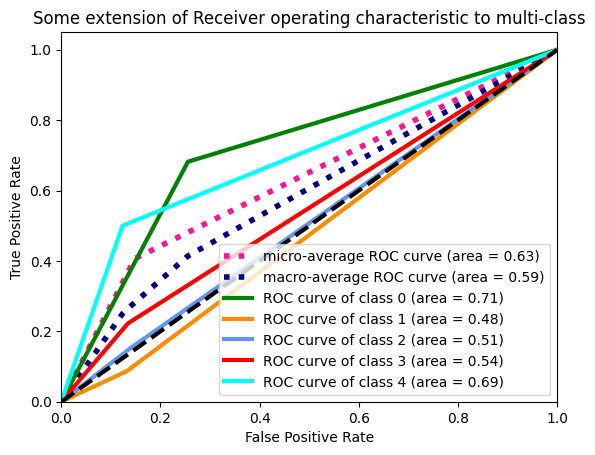

In [23]:
#ROC curve for SVM

from sklearn.preprocessing import label_binarize
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])


y_score1 = label_binarize(y_pred1, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from scipy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

<ipython-input-24-d8f3590c6eb6>:31: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


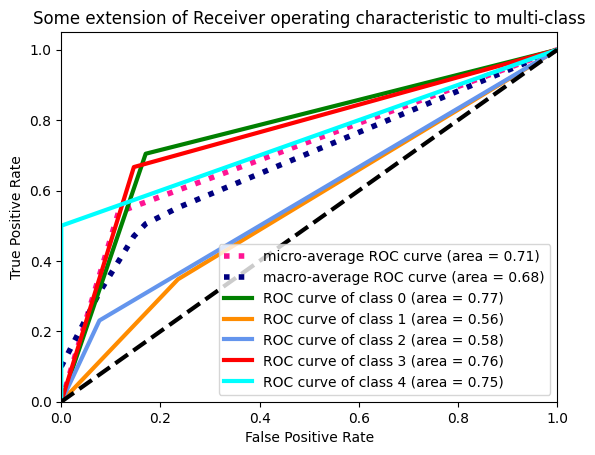

In [24]:
#ROC curve for ANN
from sklearn.preprocessing import label_binarize
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])


y_score1 = label_binarize(y_pred4, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from scipy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

<ipython-input-25-4ecf9aeb1f3d>:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


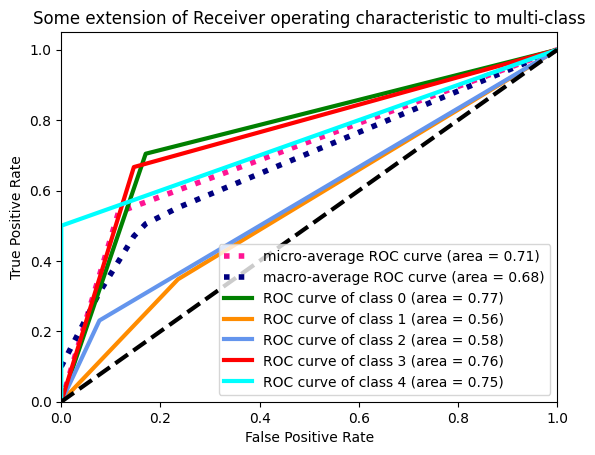

In [25]:
#ROC curve for (ANN+SVM)

from sklearn.preprocessing import label_binarize
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])


y_score1 = label_binarize(out, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from scipy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

# Contribution code : We have done one contribution part for binary using KNN and Gradient boosting models

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

dataset = pd.read_csv("/content/sample_data/binary classification.csv")
dataset_array = dataset.to_numpy()
x = dataset_array[:, 0:13]  # Extracting features from columns 0 to 12
y = dataset_array[:, 13]    # Extracting labels from column 13

In [28]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True, random_state=42)

# StandardScaler for normalization
scaler = StandardScaler()

# Min-max scaler for normalization
scaler_minmax = MinMaxScaler(feature_range=(0, 1))

In [29]:
# KNN model
model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(scaler_minmax.fit_transform(X_train), y_train)
predictions1 = model1.predict_proba(scaler_minmax.transform(X_test))
y_pred1 = model1.predict(scaler_minmax.transform(X_test))

# Gradient Boosting model
model2 = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42)
model2.fit(X_train, y_train)
predictions2 = model2.predict_proba(X_test)
y_pred2 = model2.predict(X_test)

In [30]:
# Weighted Fusion
best_accuracy = 0
best_p = 0

# Selecting the best value for p and q
p = 1
for i in range(19):
    p = p - 0.05
    q = 1 - p

    mixed = predictions1[:, 1] * p + predictions2[:, 1] * q
    rounded_mixed = (mixed > 0.5).astype(int)

    score = accuracy_score(rounded_mixed, y_test)
    print("  mixed  p  q", "%.4f" % score, "%.2f" % p, "%.2f" % q)

    # Update the best parameters if the current accuracy is higher
    if score > best_accuracy:
        best_accuracy = score
        best_p = p

# After selecting the best value of p and q
mixed = predictions1[:, 1] * best_p + predictions2[:, 1] * (1 - best_p)
rounded_mixed = (mixed > 0.5).astype(int)

# Evaluate accuracy, confusion matrix, and classification report for each model and fusion
accuracy_algo1_test = accuracy_score(y_test, y_pred1)
accuracy_algo2_test = accuracy_score(y_test, y_pred2)
accuracy_fusion_test = accuracy_score(y_test, rounded_mixed)


  mixed  p  q 0.8462 0.95 0.05
  mixed  p  q 0.8462 0.90 0.10
  mixed  p  q 0.8462 0.85 0.15
  mixed  p  q 0.8242 0.80 0.20
  mixed  p  q 0.7912 0.75 0.25
  mixed  p  q 0.7802 0.70 0.30
  mixed  p  q 0.7802 0.65 0.35
  mixed  p  q 0.7692 0.60 0.40
  mixed  p  q 0.7692 0.55 0.45
  mixed  p  q 0.7582 0.50 0.50
  mixed  p  q 0.7582 0.45 0.55
  mixed  p  q 0.7473 0.40 0.60
  mixed  p  q 0.7473 0.35 0.65
  mixed  p  q 0.7473 0.30 0.70
  mixed  p  q 0.7473 0.25 0.75
  mixed  p  q 0.7473 0.20 0.80
  mixed  p  q 0.7473 0.15 0.85
  mixed  p  q 0.7473 0.10 0.90
  mixed  p  q 0.7473 0.05 0.95


In [31]:
print("Algorithm 1 Accuracy on Test Set:", accuracy_algo1_test)
print("Algorithm 2 Accuracy on Test Set:", accuracy_algo2_test)
print("Weighted Fusion Accuracy on Test Set:", accuracy_fusion_test)

print("\nConfusion Matrix for Algorithm 1:")
print(confusion_matrix(y_test, y_pred1))

print("\nConfusion Matrix for Algorithm 2:")
print(confusion_matrix(y_test, y_pred2))

print("\nConfusion Matrix for Weighted Fusion:")
print(confusion_matrix(y_test, rounded_mixed))

print("\nClassification Report for Algorithm 1:")
print(classification_report(y_test, y_pred1))

print("\nClassification Report for Algorithm 2:")
print(classification_report(y_test, y_pred2))

print("\nClassification Report for Weighted Fusion:")
print(classification_report(y_test, rounded_mixed))

Algorithm 1 Accuracy on Test Set: 0.8461538461538461
Algorithm 2 Accuracy on Test Set: 0.7582417582417582
Weighted Fusion Accuracy on Test Set: 0.8461538461538461

Confusion Matrix for Algorithm 1:
[[40  8]
 [ 6 37]]

Confusion Matrix for Algorithm 2:
[[37 11]
 [11 32]]

Confusion Matrix for Weighted Fusion:
[[40  8]
 [ 6 37]]

Classification Report for Algorithm 1:
              precision    recall  f1-score   support

         0.0       0.87      0.83      0.85        48
         1.0       0.82      0.86      0.84        43

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91


Classification Report for Algorithm 2:
              precision    recall  f1-score   support

         0.0       0.77      0.77      0.77        48
         1.0       0.74      0.74      0.74        43

    accuracy                           0.76        91
   macro avg       0.76      0.76      0.76   

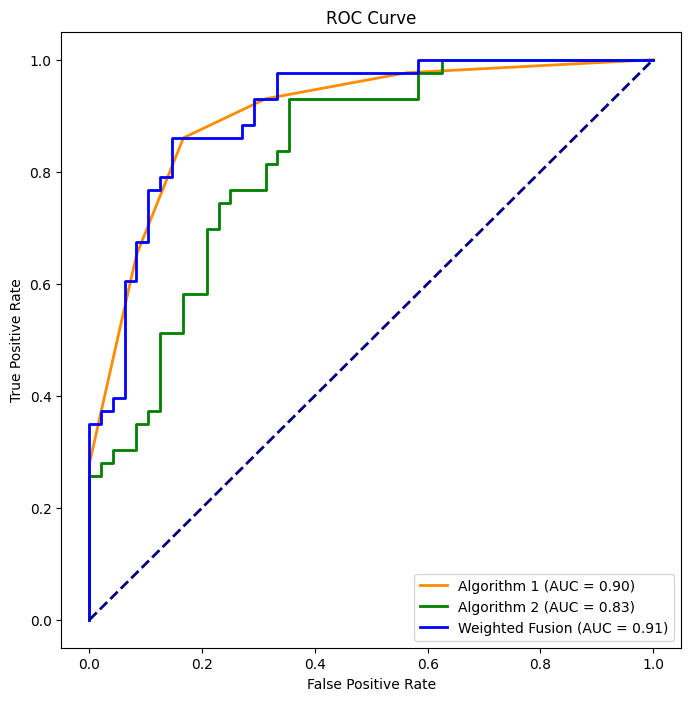

In [32]:
# ROC curve for Algorithm 1
fpr_algo1, tpr_algo1, _ = roc_curve(y_test, predictions1[:, 1])
roc_auc_algo1 = auc(fpr_algo1, tpr_algo1)

# ROC curve for Algorithm 2
fpr_algo2, tpr_algo2, _ = roc_curve(y_test, predictions2[:, 1])
roc_auc_algo2 = auc(fpr_algo2, tpr_algo2)

# ROC curve for Weighted Fusion
fpr_fusion, tpr_fusion, _ = roc_curve(y_test, mixed)
roc_auc_fusion = auc(fpr_fusion, tpr_fusion)

# Plotting ROC curves
plt.figure(figsize=(8, 8))
plt.plot(fpr_algo1, tpr_algo1, color='darkorange', lw=2, label='Algorithm 1 (AUC = {:.2f})'.format(roc_auc_algo1))
plt.plot(fpr_algo2, tpr_algo2, color='green', lw=2, label='Algorithm 2 (AUC = {:.2f})'.format(roc_auc_algo2))
plt.plot(fpr_fusion, tpr_fusion, color='blue', lw=2, label='Weighted Fusion (AUC = {:.2f})'.format(roc_auc_fusion))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


# Conclusion and Future Direction

<li>In this research project, the implementation of fused prediction models for the identification of patients with cardiovascular disease (CVD) using machine learning algorithms has shown promising results. The use of various machine learning techniques such as artificial neural network, SVM, logistic regression, decision tree, random forest, and AdaBoost, along with a fusion approach, has demonstrated improved performance in both binary and multiclass classification of heart disease.</li>
<br>

<li>The results claimed in the paper indicate that the proposed weighted fusion approach achieved higher accuracy (93-95%) in binary classification and respectable accuracy (72-75%) in multiclass classification compared to individual algorithms.We have replicated one fusion model for each binary and multi classification.In binary fusion model (Random forest = 0.82, ANN = 0.85 and fusion =0.86 accuracy was achieved) and in multi- class fusion model (Support Vector Machine = 0.538, Fusion = 0.5824 and ANN = 0.58 was achieved) and in our contribution fusion model (KNN = 0.90,Gradient boosting= 0.83, fusion model = 0.91) was achieved. The contribution that we have done using KNN and gradient boosting models for the binary classification seems to perform better in terms of accuracy as compared to the fusion model of random forest and ANN given in the research paper as there is a better accuracy at 0.91. The fusion models effectively reduced risk factors and improved overall output in terms of accuracy and efficiency. The decision scores from each algorithm were combined using a weighted sum rule, leading to a more reliable and robust predictive model for CVD.</li>
<br>
<li>However, it's important to acknowledge certain limitations in the study. Despite the improvements in accuracy, the increase in performance after fusion was modest (1-3%), suggesting that there may be diminishing returns with the current approach. Additionally, the study does not extensively discuss the interpretability of the models, which is crucial for real-world applications, especially in the healthcare sector where transparency and understanding of predictions are paramount.</li>
<br>

<li>For future directions, researchers could explore ways to enhance interpretability of the models and investigate the generalizability of the proposed approach across diverse datasets. The fusion model could be tested on larger and more diverse datasets to assess its robustness and applicability to different populations. Moreover, continuous refinement and optimization of the model could be pursued to achieve higher performance gains.</li>
<br>

<li>In terms of real-world applications, the research envisions the development of mobile applications or web-based platforms for physicians to easily access and update patient information, providing quick and accurate predictions with risk factor analysis. The proposed weighted fusion approach could be extended to other diseases, broadening its applicability in the field of healthcare.</li>

**In conclusion, while the research has made significant strides in developing a fused prediction model for CVD, there is still room for improvement, particularly in interpretability and generalizability. The findings provide a strong foundation for future research and development of practical applications in healthcare**

# References:

* [1]:H. B. Kibria and A. Matin, “The severity prediction of the binary and multi-class cardiovascular disease–a machine learning-based fu- sion approach,” arXiv preprint arXiv:2203.04921, 2022.
* [7]:Karthikeyan Harimoorthy and Menakadevi Thangavelu. ,Multi-disease prediction model using improved svmradial bias technique in healthcare monitoring system. Journal of Ambient Intelligence and Humanized Computing,pages 1–9, 2020.
* [14] Haleh Ayatollahi, Leila Gholamhosseini, and Masoud Salehi. Predicting coronary artery disease: a comparison
between two data mining algorithms. BMC public health, 19(1):1–9, 2019.
* [22]:Mofreh A Hogo. A proposed gender-based approach for diagnosis of the coronary artery disease. SN Applied
Sciences, 2:1–17, 2020.
* [23] Ayman Mir and Sudhir N Dhage. Diabetes disease prediction using machine learning on big data of healthcare. In
2018 Fourth International Conference on Computing Communication Control and Automation (ICCUBEA), pages
1–6. IEEE, 2018.
* [38]: Huma Naz and Sachin Ahuja. Deep learning approach for diabetes prediction using pima indian dataset. Journal
of Diabetes & Metabolic Disorders, 19(1):391–403, 2020.
* [39] Davide Chicco and Giuseppe Jurman. Machine learning can predict survival of patients with heart failure from
serum creatinine and ejection fraction alone. BMC medical informatics and decision making, 20(1):16, 2020.
* [40] Kaladevi AC Ramya Perumal. Early prediction of coronary heart disease from cleveland dataset using machine
learning techniques. International Journal of Advanced Science and Technology, 29(06):4225 – 4234, May 2020
* [41] Md Nahiduzzaman, Md Julker Nayeem, Md Toukir Ahmed, and Md Shahid Uz Zaman. Prediction of heart disease
using multi-layer perceptron neural network and support vector machine. In 2019 4th International Conference on
Electrical Information and Communication Technology (EICT), pages 1–6. IEEE, 2019.
* [42] Animesh Kumar Paul, Pintu Chandra Shill, Md Rafiqul Islam Rabin, and Kazuyuki Murase. Adaptive weighted
fuzzy rule-based system for the risk level assessment of heart disease. Applied Intelligence, 48(7):1739–1756, 2018.
* [43] Oluwarotimi Williams Samuel, Grace Mojisola Asogbon, Arun Kumar Sangaiah, Peng Fang, and Guanglin Li. An
integrated decision support system based on ann and fuzzy_ahp for heart failure risk prediction. Expert Systems
with Applications, 68:163–172, 2017.
